
# CAP4453 Assignment 2 — **Two‑Layer CNN (Minimal Template)**

This notebook is a **bare‑bones scaffold** for your Assignment 2 experiments.  
It includes **only** a two‑layer CNN example and **clearly marked** `# STUDENT TODO:`:
- **Data augmentation**
- **Image normalisation** (in the dataloader)
- **Batch Normalisation** (inside the model)
- **Optimizer & LR scheduler**
- **Training / validation / test loops**
- **Plots & analysis (e.g., misclassified examples)**

> **Important:** You must **design any deeper CNNs yourself** (e.g., 3‑layer or more). Do **not** expect ready‑made models here. You could design it in this notebook or in any other notebook/python files.



## Next steps
- **Architectural variations:** Modify the number of filters (`hidden_channels1`, `hidden_channels2`), change kernel sizes, or try different pooling strategies.
- **Make CNN deeper:** Add one or two extra convolutional layers. Does a deeper network improve accuracy?
- **Data augmentation:** Add transforms such as random cropping, horizontal flipping, colour jitter, and small rotations.
- **Data Normalisation:** Use `transforms.Normalize(mean, std)` in the **dataloader** after `ToTensor()`.
- **Batch Normalisation:** Insert `nn.BatchNorm2d(num_channels)` **after** `nn.Conv2d` and **before** `nn.ReLU()` in each block.
- **Comparison with Assignment 1:** Train your best 2‑layer and 3-layer CNNs and report test/val accuracy. Compare to Assignment 1’s linear and two‑layer fully connected baselines.
- **Analysis:** Identify misclassified examples and discuss patterns.


## 1. Setup (imports, device, seeds)

In [1]:
# %pip install "numpy<2"

In [2]:
# Minimal imports
import os, random, time
from typing import Tuple

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

# Seed cell 
SEED = 42
random.seed(SEED) 
np.random.seed(SEED) 
torch.manual_seed(SEED) 
torch.cuda.manual_seed_all(SEED)

# Device (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cpu



## 2. Datasets & Transforms (augmentation + image normalisation)

- Switch dataset with `dataset_name`.
- **Add augmentation** inside the marked list(s).
- **Add image normalisation** via `transforms.Normalize(mean, std)` **after** `transforms.ToTensor()`.
- Keep augmentation **ON** for train only; for val/test typically only `ToTensor()` and **normalisation**.


In [3]:
# Use the CIFAR10 Dataset.
dataset_name = 'cifar10'  # 'cifar10' or 'mnist'  (STUDENT TODO)
AUGMENT      = True       # Apply CIFAR-10 training augmentation.
USE_NORMALIZE = True      # Turn on for CIFAR-10 stats.

# Moderate batch size for stable updates without using too much memory.
batch_size = 64

# Changed validation ratio to 20% instead of 10%.
val_ratio  = 0.2

# --- Build transforms ---
if dataset_name.lower() == 'cifar10':
    # TRAIN transforms (add augmentation in the list below)
    train_tfms_list = []
    if AUGMENT:
        train_tfms_list += [transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(p=0.5)]
    train_tfms_list += [transforms.ToTensor()]  # required
    
    if USE_NORMALIZE:
        # Adds typical CIFAR-10 stats.
        cifar10_mean = (0.4914, 0.4822, 0.4465)
        cifar10_std = (0.2470, 0.2435, 0.2616)
        train_tfms_list += [transforms.Normalize(mean=cifar10_mean, std=cifar10_std)]
        pass
    
    test_tfms_list = [transforms.ToTensor()]
    
    if USE_NORMALIZE:
        # STUDENT TODO: same normalisation as train
        test_tfms_list += [transforms.Normalize(mean=cifar10_mean, std=cifar10_std)]
        pass
    
    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms  = transforms.Compose(test_tfms_list)

    train_dataset = datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_tfms)
    test_dataset  = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_tfms)
    num_classes = 10
    in_channels = 3

elif dataset_name.lower() == 'mnist':
    train_tfms_list = []
    if AUGMENT:
        # STUDENT TODO (AUGMENT for MNIST): small rotations/affine
        # e.g., transforms.RandomRotation(10)
        pass
    train_tfms_list += [transforms.ToTensor()]
    
    if USE_NORMALIZE:
        # STUDENT TODO (IMAGE NORMALISATION): typical MNIST stats
        # train_tfms_list += [transforms.Normalize(mean=(0.1307,), std=(0.3081,))]
        pass
    
    test_tfms_list = [transforms.ToTensor()]
    if USE_NORMALIZE:
        # STUDENT TODO: same normalisation as train
        # test_tfms_list += [transforms.Normalize(mean=(0.1307,), std=(0.3081,))]
        pass
    
    train_tfms = transforms.Compose(train_tfms_list)
    test_tfms  = transforms.Compose(test_tfms_list)

    train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=train_tfms)
    test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=test_tfms)
    num_classes = 10
    in_channels = 1
else:
    raise ValueError('Unknown dataset: choose cifar10 or mnist')

# --- Train/Val split ---
train_size = int((1.0 - val_ratio) * len(train_dataset))
val_size   = len(train_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_dataset)}')


Files already downloaded and verified
Files already downloaded and verified
Train: 40000 | Val: 10000 | Test: 10000



## 3. Two‑Layer CNN (only) — add BatchNorm where marked

> You must create **any deeper CNNs** in a **separate class** (your own file or below), using this as a starting point.


In [4]:
class TwoLayerCNN(nn.Module):
    """A minimal two‑layer CNN.
    Block1: Conv -> (BatchNorm?) -> ReLU -> Pool
    Block2: Conv -> (BatchNorm?) -> ReLU -> Pool
    FC:     Linear to num_classes (lazy‑init after first forward)
    """
    def __init__(self, in_channels, num_classes, hidden_channels1=16, hidden_channels2=32, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        # --- Block 1 ---
        self.conv1 = nn.Conv2d(in_channels, hidden_channels1, kernel_size=3, padding=1, bias=not use_bn)
        self.bn1 = nn.BatchNorm2d(hidden_channels1) if use_bn else nn.Identity()
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2)

        # --- Block 2 ---
        self.conv2 = nn.Conv2d(hidden_channels1, hidden_channels2, kernel_size=3, padding=1, bias=not use_bn)
        self.bn2 = nn.BatchNorm2d(hidden_channels2) if use_bn else nn.Identity()
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2)

        # Classifier head will be created lazily (first forward) so you don't need to compute shapes by hand
        self.classifier = None
        self.num_classes = num_classes

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        if self.classifier is None:
            self.classifier = nn.Linear(x.size(1), self.num_classes).to(x.device)
        return self.classifier(x)


class ThreeLayerCNN(nn.Module):
    # Three convolution blocks with 16, 32, and 64 channels, then a linear classifier.
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.LazyLinear(num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)



In [5]:
# STUDENT TODO: create your OWN deeper CNN class (e.g., ThreeLayerCNN) in another cell/file.
# Do NOT expect a prewritten deeper network here.


## 4. Optimizer & (optional) LR scheduler

In [6]:
learning_rate = 5e-4      
weight_decay  = 5e-4      
momentum      = 0.9      

model = TwoLayerCNN(in_channels, num_classes, use_bn=False).to(device)
# model = ThreeLayerCNN(in_channels, num_classes).to(device)

# Example choices (uncomment ONE):
# optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)  
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)                    
# optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=momentum)  

# STUDENT TODO (optional): uncomment LR scheduler for better accuracy
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

criterion = nn.CrossEntropyLoss()
print(model)


TwoLayerCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): Identity()
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): Identity()
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


## 5. Training / Validation — skeleton to complete

In [7]:
# Standard training & evaluation.
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += batch_size

    if total_examples == 0:
        raise ValueError('train_loader yielded no examples')

    avg_loss = total_loss / total_examples
    avg_acc = 100.0 * total_correct / total_examples
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_examples += batch_size

    if total_examples == 0:
        raise ValueError('loader yielded no examples')

    avg_loss = total_loss / total_examples
    avg_acc = 100.0 * total_correct / total_examples
    return avg_loss, avg_acc


## 6. Run training (log metrics, make plots)

Epoch 01/30 | Train 2.1304/21.88% | Val 2.0111/27.13%
Epoch 02/30 | Train 1.9631/28.66% | Val 1.9218/30.69%
Epoch 03/30 | Train 1.8995/31.80% | Val 1.8754/32.74%
Epoch 04/30 | Train 1.8614/33.16% | Val 1.8494/33.65%
Epoch 05/30 | Train 1.8293/34.46% | Val 1.8201/35.18%
Epoch 06/30 | Train 1.8108/35.08% | Val 1.7987/35.67%
Epoch 07/30 | Train 1.7884/36.19% | Val 1.7832/36.35%
Epoch 08/30 | Train 1.7735/36.70% | Val 1.7698/36.90%
Epoch 09/30 | Train 1.7630/37.07% | Val 1.7669/37.19%
Epoch 10/30 | Train 1.7540/37.40% | Val 1.7523/37.26%
Epoch 11/30 | Train 1.7459/37.68% | Val 1.7273/38.69%
Epoch 12/30 | Train 1.7334/38.14% | Val 1.7283/38.15%
Epoch 13/30 | Train 1.7262/38.19% | Val 1.7162/39.17%
Epoch 14/30 | Train 1.7164/38.97% | Val 1.7224/38.65%
Epoch 15/30 | Train 1.7122/38.81% | Val 1.7027/39.36%
Epoch 16/30 | Train 1.7101/38.85% | Val 1.7065/39.46%
Epoch 17/30 | Train 1.6987/39.27% | Val 1.6958/39.50%
Epoch 18/30 | Train 1.6904/39.66% | Val 1.7011/38.63%
Epoch 19/30 | Train 1.6928/3

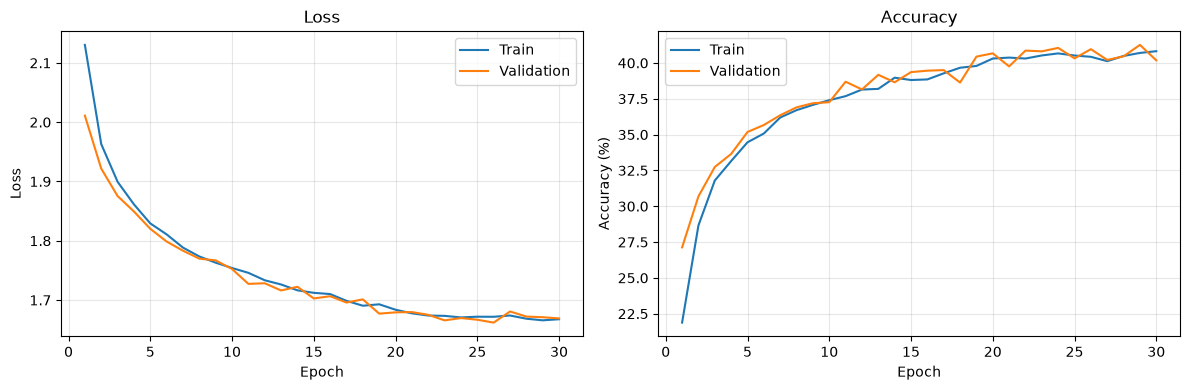

In [8]:
num_epochs = 30  # STUDENT TODO

train_hist, val_hist = [], []

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    train_hist.append((tr_loss, tr_acc))
    val_hist.append((va_loss, va_acc))
    if scheduler is not None:
        scheduler.step()
    print(f'Epoch {epoch:02d}/{num_epochs} | Train {tr_loss:.4f}/{tr_acc:.2f}% | Val {va_loss:.4f}/{va_acc:.2f}%')

epochs = range(1, num_epochs + 1)
train_losses = [metrics[0] for metrics in train_hist]
val_losses = [metrics[0] for metrics in val_hist]
train_accuracies = [metrics[1] for metrics in train_hist]
val_accuracies = [metrics[1] for metrics in val_hist]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label='Train')
axes[0].plot(epochs, val_losses, label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, train_accuracies, label='Train')
axes[1].plot(epochs, val_accuracies, label='Validation')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Analysis — misclassified examples (optional)

In [9]:
# STUDENT TODO: display a small grid of misclassified images
# Hints:
# - collect logits, compare argmax with true labels, store a few errors
# - if you used Normalize, consider an inverse normalisation for display
# - use matplotlib to show images with predicted/true labels
